# Exercise 2.11 (programming)

Make a figure analogous to Figure 2.6 for the nonstationary case outlined in Exercise 2.5. Include the constant-step-size epsilon-greedy algorithm with alpha = 0.1. Use runs of 200,000 steps and, as a performance measure for each algorithm and parameter setting, use the average reward over the last 100,000 steps.

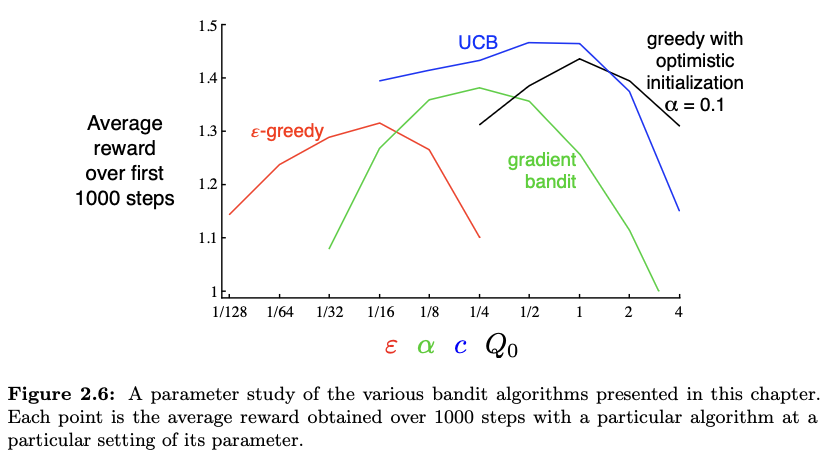

- so basically I need to implement 4 versions of bandit algorithm, run each for N steps, calculate average reward for different hyperparameter values.
- first, let's make stationary version, then change it to non-stationary.

Tasks:
1. Prepare bandit algorithms:
   1. eps-greedy;
   2. UCB;
   3. gradient bandit;
   4. greedy with optimistic initialization;
2. Initialize hyperparameter space;
3. Run for N steps each bandit with different hyperparam value and collect average reward;
4. Build plot as in Fig. 2.6;
5. Complete 1-4 steps for (non-)stationary case.

## Imports

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sts
from tqdm import tqdm

### Prepare algorithms

In [125]:
def bandit_alg_eps_greedy(q_opt, eps, stationary=True):
    alpha = 0.1
    Q = np.zeros(shape=k) # estimated value of action
    N = np.zeros(shape=k) # number of times action was chosen

    reward_list = []
    
    for _ in range(total_steps):
        if not stationary:
            q_opt += np.random.normal(0, 0.01, size=k)
        val = np.random.uniform(0, 1)
        action = np.random.randint(0, k) if val < eps else np.argmax(Q)

        N[action] += 1
        reward = np.random.normal(q_opt[action], 1)
        
        # Q[action] += (1 / N[action]) * (reward - Q[action])
        Q[action] += alpha * (reward - Q[action])
        
        reward_list.append(reward)        

    average_reward = np.mean(reward_list[-steps_window:])

    return average_reward

In [126]:
def bandit_alg_ucb(q_opt, c, stationary=True):
    alpha = 0.1
    Q = np.zeros(shape=k) # estimated value of action
    N = np.zeros(shape=k) # number of times action was chosen

    reward_list = []
    
    for t in range(total_steps):
        if not stationary:
            q_opt += np.random.normal(0, 0.01, size=k)
        action = np.argmax(Q + c * np.sqrt(np.log(t + 1) / (N + 1)))

        N[action] += 1
        reward = np.random.normal(q_opt[action], 1)
        
        Q[action] += alpha * (reward - Q[action])
        reward_list.append(reward)        

    average_reward = np.mean(reward_list[-steps_window:])

    return average_reward

In [127]:
def bandit_alg_gradient(q_opt, alpha, stationary=True):
    H = np.zeros(shape=k) # preference for each action

    reward_list = []
    
    reward_avg = 0
    
    for t in range(total_steps):
        if not stationary:
            q_opt += np.random.normal(0, 0.01, size=k)
        action_prob = np.exp(H) / np.sum(np.exp(H))
        action = np.random.choice(np.arange(k), p=action_prob)

        reward = np.random.normal(q_opt[action], 1)
        reward_list.append(reward)
        reward_avg += 1 / (t + 1) * (reward - reward_avg)

        predicate = np.zeros(k, dtype=int)
        predicate[action] = 1

        H += alpha * (reward - reward_avg) * (predicate - action_prob)
        
        # H[action] += alpha * (reward - reward_avg) * (1 - action_prob[action])
        # for a in range(k):
        #     if a != action:
        #         H[a] -= alpha * (reward - reward_avg) * action_prob[a]

    average_reward = np.mean(reward_list[-steps_window:])

    return average_reward

In [128]:
def bandit_alg_greedy_optimistic_init(q_opt, Q_init, stationary=True):
    alpha = 0.1
    Q = np.ones(shape=k) * Q_init # estimated value of action
    N = np.zeros(shape=k) # number of times action was chosen

    reward_list = []
    
    for _ in range(total_steps):
        if not stationary:
            q_opt += np.random.normal(0, 0.01, size=k)
        action = np.argmax(Q)

        N[action] += 1
        reward = np.random.normal(q_opt[action], 1)
        
        # Q[action] += (1 / N[action]) * (reward - Q[action])
        Q[action] += alpha * (reward - Q[action])
        
        reward_list.append(reward)        

    average_reward = np.mean(reward_list[-steps_window:])

    return average_reward

### Prepare hyperparamete space and collect rewards

In [122]:
total_steps = 10_000
steps_window = 10_000
alpha = 0.1
k = 10
eps = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4]
alpha = [1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
c = [1/16, 1/8, 1/4, 1/2, 1, 2, 4]
Q_init = [1/4, 1/2, 1, 2, 4]

## Stationary

### Collect rewards

In [123]:
eps_reward = []
ucb_reward = []
gradient_reward = []
greedy_reward = []

for r in tqdm(range(100)):
    q_opt = np.random.normal(0, 1, k)

    eps_reward.append([bandit_alg_eps_greedy(q_opt, e) for e in eps])
    gradient_reward.append([bandit_alg_gradient(q_opt, a) for a in alpha])
    ucb_reward.append([bandit_alg_ucb(q_opt, c_param) for c_param in c])
    greedy_reward.append([bandit_alg_greedy_optimistic_init(q_opt, q) for q in Q_init])

100%|██████████| 100/100 [02:20<00:00,  1.41s/it]


### Build plots

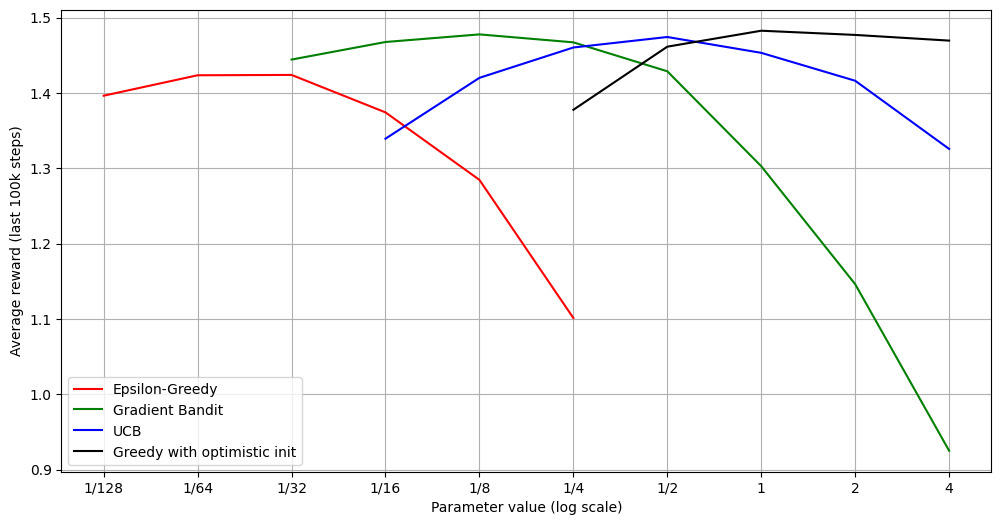

In [129]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=eps, y=np.mean(eps_reward, axis=0), label='Epsilon-Greedy', color="red")
sns.lineplot(x=alpha, y=np.mean(gradient_reward, axis=0), label="Gradient Bandit", color="green")
sns.lineplot(x=c, y=np.mean(ucb_reward, axis=0), label="UCB", color="blue")
sns.lineplot(x=Q_init, y=np.mean(greedy_reward, axis=0), label="Greedy with optimistic init", color="black")
plt.xscale('log', base=2)
plt.xlabel('Parameter value (log scale)')
plt.ylabel('Average reward (last 100k steps)')
plt.grid()
plt.xticks(
    ticks=[1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4],
    labels=['1/128', '1/64', '1/32', '1/16', '1/8', '1/4', '1/2', '1', '2', '4']
);

- characteristic parameter plots have inverted U-shapes as in example;

## Same but for non-stationary case

### Collect rewards

In [130]:
eps_reward = []
ucb_reward = []
gradient_reward = []
greedy_reward = []

for r in tqdm(range(100)):
    q_opt = np.random.normal(0, 1, k)

    eps_reward.append([bandit_alg_eps_greedy(q_opt, e, stationary=False) for e in eps])
    gradient_reward.append([bandit_alg_gradient(q_opt, a, stationary=False) for a in alpha])
    ucb_reward.append([bandit_alg_ucb(q_opt, c_param, stationary=False) for c_param in c])
    greedy_reward.append([bandit_alg_greedy_optimistic_init(q_opt, q, stationary=False) for q in Q_init])

100%|██████████| 100/100 [02:50<00:00,  1.71s/it]


### Build plots

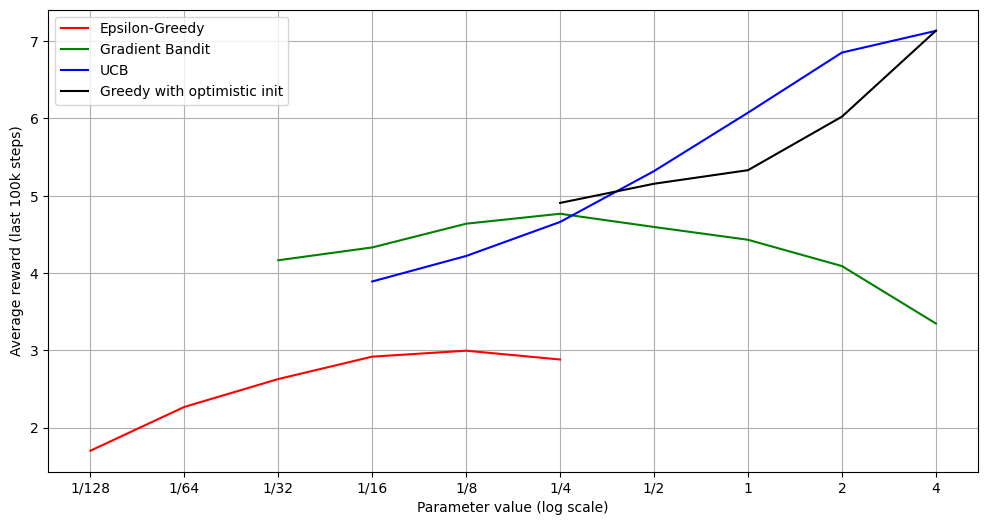

In [131]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=eps, y=np.mean(eps_reward, axis=0), label='Epsilon-Greedy', color="red")
sns.lineplot(x=alpha, y=np.mean(gradient_reward, axis=0), label="Gradient Bandit", color="green")
sns.lineplot(x=c, y=np.mean(ucb_reward, axis=0), label="UCB", color="blue")
sns.lineplot(x=Q_init, y=np.mean(greedy_reward, axis=0), label="Greedy with optimistic init", color="black")
plt.xscale('log', base=2)
plt.xlabel('Parameter value (log scale)')
plt.ylabel('Average reward (last 100k steps)')
plt.grid()
plt.xticks(
    ticks=[1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4],
    labels=['1/128', '1/64', '1/32', '1/16', '1/8', '1/4', '1/2', '1', '2', '4']
);

- in non-stationary case parameter characteristic plots don't have explicit inverted U-shapes;